# ***Diabetes_Dataset***

***Introduction***


This dataset provides a comprehensive collection of demographic, behavioral,
and clinical information for 100,000 individuals, designed to support advanced research and predictive modeling
in the field of diabetes. By integrating key variables such as age, gender, race, location, BMI, HbA1c levels,
blood glucose levels, hypertension, heart disease, and smoking history, the dataset enables in-depth analyses of
both biological and sociodemographic determinants of diabetes.

## ***Part 1:Data Loading***

Loading and Reading a data file

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
!pip install xgboost
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score


In [94]:
df=pd.read_csv('diabetes_dataset.csv')

df   # Jupyter shortcut for displaying the object (not exactly "printing")
display(df) # displays the df in a rich, nicely formatted way

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,clinical_notes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0,"Overweight, advised dietary and exercise modif..."
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0,Healthy BMI range.
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0,"Young patient, generally lower risk but needs ..."
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0,"Overweight, advised dietary and exercise modif..."
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0,"Healthy BMI range. High HbA1c level, indicativ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2018,Female,33.0,Wyoming,0,0,0,0,1,0,0,never,21.21,6.5,90,0,"Healthy BMI range. High HbA1c level, indicativ..."
99996,2016,Female,80.0,Wyoming,0,1,0,0,0,0,0,No Info,36.66,5.7,100,0,Elderly patient with increased risk of chronic...
99997,2018,Male,46.0,Wyoming,0,1,0,0,0,0,0,ever,36.12,6.2,158,0,"Obese category, increased risk for diabetes an..."
99998,2018,Female,51.0,Wyoming,1,0,0,0,0,0,0,not current,29.29,6.0,155,0,"Overweight, advised dietary and exercise modif..."


In [95]:
#  copy of your data
df_copy= df.copy()
df_copy

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,clinical_notes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0,"Overweight, advised dietary and exercise modif..."
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0,Healthy BMI range.
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0,"Young patient, generally lower risk but needs ..."
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0,"Overweight, advised dietary and exercise modif..."
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0,"Healthy BMI range. High HbA1c level, indicativ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2018,Female,33.0,Wyoming,0,0,0,0,1,0,0,never,21.21,6.5,90,0,"Healthy BMI range. High HbA1c level, indicativ..."
99996,2016,Female,80.0,Wyoming,0,1,0,0,0,0,0,No Info,36.66,5.7,100,0,Elderly patient with increased risk of chronic...
99997,2018,Male,46.0,Wyoming,0,1,0,0,0,0,0,ever,36.12,6.2,158,0,"Obese category, increased risk for diabetes an..."
99998,2018,Female,51.0,Wyoming,1,0,0,0,0,0,0,not current,29.29,6.0,155,0,"Overweight, advised dietary and exercise modif..."


## ***Part 2: Initial Data Inspection/Exploration***

Before conducting any analysis, it is essential to inspect the diabetes dataset to gain a preliminary understanding of its structure and quality. This includes viewing the first few rows, checking data types, confirming non-null counts, and identifying the overall shape of the dataset. These steps help reveal common issues in medical data, such as missing clinical values, zeros used in place of missing measurements, incorrect data types, or unusual outliers. Early detection of these problems ensures that appropriate cleaning and preprocessing steps can be applied later, allowing for more accurate and reliable analysis.

### Preview Dataset and its dimensions

In [96]:
display(df.head())
display(df.tail())
#Display the first 5 rows of the DataFrame using the .head()


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,clinical_notes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0,"Overweight, advised dietary and exercise modif..."
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0,Healthy BMI range.
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0,"Young patient, generally lower risk but needs ..."
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0,"Overweight, advised dietary and exercise modif..."
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0,"Healthy BMI range. High HbA1c level, indicativ..."


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,clinical_notes
99995,2018,Female,33.0,Wyoming,0,0,0,0,1,0,0,never,21.21,6.5,90,0,"Healthy BMI range. High HbA1c level, indicativ..."
99996,2016,Female,80.0,Wyoming,0,1,0,0,0,0,0,No Info,36.66,5.7,100,0,Elderly patient with increased risk of chronic...
99997,2018,Male,46.0,Wyoming,0,1,0,0,0,0,0,ever,36.12,6.2,158,0,"Obese category, increased risk for diabetes an..."
99998,2018,Female,51.0,Wyoming,1,0,0,0,0,0,0,not current,29.29,6.0,155,0,"Overweight, advised dietary and exercise modif..."
99999,2016,Male,13.0,Wyoming,0,0,0,1,0,0,0,No Info,17.16,5.0,90,0,"Young patient, generally lower risk but needs ..."


In [97]:
df.info()
#The .info() method provides a concise summary of the DataFrame.
#It includes the index dtype and columns, non-null values and their data types, and memory usage.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  object 
 2   age                   100000 non-null  float64
 3   location              100000 non-null  object 
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  object 
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100000 non-null  int64  
 15  d

In [98]:
df.shape
#The .shape attribute of a DataFrame returns the number of rows and the number of columns.

(100000, 17)

### Renaming columns

In [99]:
# Rename the smoking_history column to a name that makes more sense and prints the df with the renamed column.
df.rename(columns={'race:AfricanAmerican':'race_AfricanAmerican'},inplace=True)
print("Column names after renaming:")
print(df)

Column names after renaming:
       year  gender   age location  race_AfricanAmerican  race:Asian  \
0      2020  Female  32.0  Alabama                     0           0   
1      2015  Female  29.0  Alabama                     0           1   
2      2015    Male  18.0  Alabama                     0           0   
3      2015    Male  41.0  Alabama                     0           0   
4      2016  Female  52.0  Alabama                     1           0   
...     ...     ...   ...      ...                   ...         ...   
99995  2018  Female  33.0  Wyoming                     0           0   
99996  2016  Female  80.0  Wyoming                     0           1   
99997  2018    Male  46.0  Wyoming                     0           1   
99998  2018  Female  51.0  Wyoming                     1           0   
99999  2016    Male  13.0  Wyoming                     0           0   

       race:Caucasian  race:Hispanic  race:Other  hypertension  heart_disease  \
0                   0    

In [100]:
# Rename the smoking_history column to a name that makes more sense and prints the df with the renamed column.
df.rename(columns={'race:Asian':'race_Asian'},inplace=True)
print("Column names after renaming:")
print(df)

Column names after renaming:
       year  gender   age location  race_AfricanAmerican  race_Asian  \
0      2020  Female  32.0  Alabama                     0           0   
1      2015  Female  29.0  Alabama                     0           1   
2      2015    Male  18.0  Alabama                     0           0   
3      2015    Male  41.0  Alabama                     0           0   
4      2016  Female  52.0  Alabama                     1           0   
...     ...     ...   ...      ...                   ...         ...   
99995  2018  Female  33.0  Wyoming                     0           0   
99996  2016  Female  80.0  Wyoming                     0           1   
99997  2018    Male  46.0  Wyoming                     0           1   
99998  2018  Female  51.0  Wyoming                     1           0   
99999  2016    Male  13.0  Wyoming                     0           0   

       race:Caucasian  race:Hispanic  race:Other  hypertension  heart_disease  \
0                   0    

In [101]:
# Rename the smoking_history column to a name that makes more sense and prints the df with the renamed column.
df.rename(columns={'race:Caucasian':'race_Caucasian'},inplace=True)
print("Column names after renaming:")
print(df)

Column names after renaming:
       year  gender   age location  race_AfricanAmerican  race_Asian  \
0      2020  Female  32.0  Alabama                     0           0   
1      2015  Female  29.0  Alabama                     0           1   
2      2015    Male  18.0  Alabama                     0           0   
3      2015    Male  41.0  Alabama                     0           0   
4      2016  Female  52.0  Alabama                     1           0   
...     ...     ...   ...      ...                   ...         ...   
99995  2018  Female  33.0  Wyoming                     0           0   
99996  2016  Female  80.0  Wyoming                     0           1   
99997  2018    Male  46.0  Wyoming                     0           1   
99998  2018  Female  51.0  Wyoming                     1           0   
99999  2016    Male  13.0  Wyoming                     0           0   

       race_Caucasian  race:Hispanic  race:Other  hypertension  heart_disease  \
0                   0    

In [102]:
# Rename the smoking_history column to a name that makes more sense and prints the df with the renamed column.
df.rename(columns={'race:Other':'race_Other'},inplace=True)
print("Column names after renaming:")
print(df)

Column names after renaming:
       year  gender   age location  race_AfricanAmerican  race_Asian  \
0      2020  Female  32.0  Alabama                     0           0   
1      2015  Female  29.0  Alabama                     0           1   
2      2015    Male  18.0  Alabama                     0           0   
3      2015    Male  41.0  Alabama                     0           0   
4      2016  Female  52.0  Alabama                     1           0   
...     ...     ...   ...      ...                   ...         ...   
99995  2018  Female  33.0  Wyoming                     0           0   
99996  2016  Female  80.0  Wyoming                     0           1   
99997  2018    Male  46.0  Wyoming                     0           1   
99998  2018  Female  51.0  Wyoming                     1           0   
99999  2016    Male  13.0  Wyoming                     0           0   

       race_Caucasian  race:Hispanic  race_Other  hypertension  heart_disease  \
0                   0    

In [103]:
# Rename the smoking_history column to a name that makes more sense and prints the df with the renamed column.
df.rename(columns={'race:Hispanic':'race_Hispanic'},inplace=True)
print("Column names after renaming:")
print(df)

Column names after renaming:
       year  gender   age location  race_AfricanAmerican  race_Asian  \
0      2020  Female  32.0  Alabama                     0           0   
1      2015  Female  29.0  Alabama                     0           1   
2      2015    Male  18.0  Alabama                     0           0   
3      2015    Male  41.0  Alabama                     0           0   
4      2016  Female  52.0  Alabama                     1           0   
...     ...     ...   ...      ...                   ...         ...   
99995  2018  Female  33.0  Wyoming                     0           0   
99996  2016  Female  80.0  Wyoming                     0           1   
99997  2018    Male  46.0  Wyoming                     0           1   
99998  2018  Female  51.0  Wyoming                     1           0   
99999  2016    Male  13.0  Wyoming                     0           0   

       race_Caucasian  race_Hispanic  race_Other  hypertension  heart_disease  \
0                   0    

In [104]:
# Rename the smoking_history column to a name that makes more sense and prints the df with the renamed column.
df.rename(columns={'smoking_history':'Smoking_Status'},inplace=True)
print("Column names after renaming:")
print(df)

Column names after renaming:
       year  gender   age location  race_AfricanAmerican  race_Asian  \
0      2020  Female  32.0  Alabama                     0           0   
1      2015  Female  29.0  Alabama                     0           1   
2      2015    Male  18.0  Alabama                     0           0   
3      2015    Male  41.0  Alabama                     0           0   
4      2016  Female  52.0  Alabama                     1           0   
...     ...     ...   ...      ...                   ...         ...   
99995  2018  Female  33.0  Wyoming                     0           0   
99996  2016  Female  80.0  Wyoming                     0           1   
99997  2018    Male  46.0  Wyoming                     0           1   
99998  2018  Female  51.0  Wyoming                     1           0   
99999  2016    Male  13.0  Wyoming                     0           0   

       race_Caucasian  race_Hispanic  race_Other  hypertension  heart_disease  \
0                   0    

In [105]:
# Rename the clinical_notes column to a name that makes more sense and prints the df with the renamed column.
df.rename(columns={'clinical_notes':'Clinical_Summary'},inplace=True)
print("Column names after renaming:")
print(df)

Column names after renaming:
       year  gender   age location  race_AfricanAmerican  race_Asian  \
0      2020  Female  32.0  Alabama                     0           0   
1      2015  Female  29.0  Alabama                     0           1   
2      2015    Male  18.0  Alabama                     0           0   
3      2015    Male  41.0  Alabama                     0           0   
4      2016  Female  52.0  Alabama                     1           0   
...     ...     ...   ...      ...                   ...         ...   
99995  2018  Female  33.0  Wyoming                     0           0   
99996  2016  Female  80.0  Wyoming                     0           1   
99997  2018    Male  46.0  Wyoming                     0           1   
99998  2018  Female  51.0  Wyoming                     1           0   
99999  2016    Male  13.0  Wyoming                     0           0   

       race_Caucasian  race_Hispanic  race_Other  hypertension  heart_disease  \
0                   0    

### Understanding data types

Understanding column data types is a critical step in analyzing the diabetes dataset, as they determine how variables can be processed and interpreted. Incorrect data types may lead to analytical errors or prevent numerical computations. Although Pandas infers data types automatically, verifying and correcting them ensures accuracy and reliability in subsequent analysis.

In [106]:
print("Data types of each column:")
display(df.dtypes)
#Display the data types of each column in the df DataFrame.

Data types of each column:


,0
year,int64
gender,object
age,float64
location,object
race_AfricanAmerican,int64
race_Asian,int64
race_Caucasian,int64
race_Hispanic,int64
race_Other,int64
hypertension,int64


***Interpretation:*** All columns have appropriate types (numeric for measurements, object for categorical data). No conversions are needed.

## Part 3: Initial Data Cleaning & Preprocessing





### Handling Missing  Values

Identifying missing values is essential, as unaddressed missing values may distort statistical results or degrade model performance.

In [107]:
# Check for missing values
display(df.isnull().sum())

,0
year,0
gender,0
age,0
location,0
race_AfricanAmerican,0
race_Asian,0
race_Caucasian,0
race_Hispanic,0
race_Other,0
hypertension,0


***Interpretation:*** There are no missing entries in the dataset, so we can proceed directly to analysis and preprocessing.

### Handling duplicates


In [108]:
#the `.duplicated()` method. This method returns a boolean Series indicating whether each row is a duplicate of a previous row. By default, it considers all columns to identify duplicates.
print("Number of duplicate rows:", df.duplicated().sum())

# Demonstrate dropping duplicates
print("\nShape of DataFrame before dropping duplicates:", df.shape)
# To remove duplicate rows, you can use the `.drop_duplicates()` method. This method returns a new DataFrame with duplicate rows removed. By default, it keeps the first occurrence of a duplicate row.
df = df.drop_duplicates()
print("Shape of DataFrame after dropping duplicates:", df.shape)

Number of duplicate rows: 14

Shape of DataFrame before dropping duplicates: (100000, 17)
Shape of DataFrame after dropping duplicates: (99986, 17)


## Part 4:Exploratory Data Analysis: Primary Statistics

**NOTE: “Exploratory Data Analysis (EDA) was conducted concurrently with data cleaning and preprocessing to iteratively identify data quality issues, understand feature distributions, and inform preprocessing decisions.”**


### Calculating Basic Statistics

Calculating basic descriptive statistics is a fundamental step in understanding the distribution, central tendency, and variability of your data.

For **numerical data**, descriptive statistics like count, mean, median, standard deviation, minimum, maximum, and quartiles provide a summary of the data's distribution.

For **categorical data**, understanding the frequency distribution of each category is crucial. This involves counting the occurrences of each unique value in a categorical column.

### Exploring Numerical Columns

### Exploring Numerical Data: Distribution and Summary Statistics

Exploring the distribution and summary statistics of numerical variables is a fundamental step in understanding the nature of your data. It helps to grasp the typical values, how spread out the data is, and the shape of its distribution.

Key aspects to consider include:

- **Central Tendency:** Measures like the mean, median, and mode indicate the center or typical value of the data.
- **Dispersion:** Measures like the standard deviation, variance, and interquartile range (IQR) describe the spread or variability of the data.
- **Shape of Distribution:** Understanding whether the data is symmetric or skewed, and if it has multiple peaks (modality), provides insights into the underlying patterns.

Summary statistics provide a quick numerical snapshot of these characteristics.

In [109]:
print("Descriptive statistics for numerical columns:")
display(df.describe()) # by defaut works only with numercial columns only

Descriptive statistics for numerical columns:


,year,age,race_AfricanAmerican,race_Asian,race_Caucasian,race_Hispanic,race_Other,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
count,99986.000000,99986.000000,99986.000000,99986.000000,99986.000000,99986.000000,99986.000000,99986.000000,99986.000000,99986.000000,99986.000000,99986.000000,99986.000000
mean,2018.360731,41.885930,0.202238,0.200098,0.198758,0.198898,0.200008,0.074860,0.039426,27.320767,5.527517,138.059518,0.085012
std,1.345312,22.516409,0.401671,0.400075,0.399067,0.399173,0.400008,0.263167,0.194606,6.637248,1.070674,40.708667,0.278901
min,2015.000000,0.080000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,2019.000000,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,2019.000000,43.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,2019.000000,60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,29.580000,6.200000,159.000000,0.000000
max,2022.000000,80.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


The .describe() output for the diabetes dataset provides key descriptive statistics that summarize the distribution of each numerical variable:

***count:*** Shows 99986 non-null observations for all variables, indicating no missing data.

***mean:*** Represents the average value—for example, the mean age is approximately 41.89, and the mean BMI is about 27.32.

***std:*** Indicates variability in the data; for instance, blood glucose level has a high standard deviation (~40.7), suggesting wide variation among patients.

***min:*** The smallest recorded value in each column (e.g., minimum age is 0.08 years).

***25% (Q1):*** The value below which 25% of observations fall, helping to understand lower-range distributions.

***50% (Median):*** The midpoint of the data—for example, median age (43) and median BMI (~27.32) reflect typical patient characteristics.

***75% (Q3):*** The value below which 75% of the data falls, showing the upper-middle range of each variable.

***max:*** The largest observed value in the column (e.g., maximum blood glucose level is 200).

These statistics provide a clear and concise overview of the central tendency, spread, and range of values within the diabetes dataset, forming the foundation for deeper analysis.

In [110]:
# 1. Calculating medians for key numerical variables
display("Median Age:", df.age.median())
display("Median BMI:", df.bmi.median())
display("Median HbA1c Level:", df.hbA1c_level.median())
display("Median Blood Glucose Level:", df.blood_glucose_level.median())

# 2. Listing unique values for categorical variables
display("Unique Locations:", df.location.unique())


# 3. Counting occurrences of categorical variables
display("Frequency of Diabetes Status (0=No, 1=Yes):")
display(df.diabetes.value_counts())
display("Frequency of Smoking Status:")
display(df.Smoking_Status.value_counts())


# 4. Grouping data and calculating mean values
# Mean BMI, HbA1c, and Blood Glucose by Diabetes Status
grouped_by_diabetes = df.groupby('diabetes')[['bmi', 'hbA1c_level', 'blood_glucose_level']].mean()
display("Mean values by Diabetes Status:")
display(grouped_by_diabetes)


# 5. Sorting data by a numerical column
# Sort patients by highest blood glucose level
sorted_by_glucose = df.sort_values(by='blood_glucose_level', ascending=False)
display("Top 10 patients by Blood Glucose Level:")
display(sorted_by_glucose.head(10))


'Median Age:'

43.0

'Median BMI:'

27.32

'Median HbA1c Level:'

...

,count
Smoking_Status,
No Info,35806
never,35091
former,9352
current,9286
not current,6447
ever,4004


'Mean values by Diabetes Status:'

,bmi,hbA1c_level,blood_glucose_level
diabetes,,,
0,26.887097,5.396751,132.853267
1,31.988382,6.934953,194.094706


'Top 10 patients by Blood Glucose Level:'

,year,gender,age,location,race_AfricanAmerican,race_Asian,race_Caucasian,race_Hispanic,race_Other,hypertension,heart_disease,Smoking_Status,bmi,hbA1c_level,blood_glucose_level,diabetes,Clinical_Summary
36386,2019,Male,62.0,Kentucky,0,1,0,0,0,0,0,current,23.32,6.1,300,1,Elderly patient with increased risk of chronic...
84100,2019,Female,47.0,South Carolina,0,0,0,1,0,1,0,current,26.33,6.6,300,1,"Overweight, advised dietary and exercise modif..."
16551,2018,Female,68.0,District of Columbia,0,1,0,0,0,1,0,No Info,27.88,6.6,300,1,Elderly patient with increased risk of chronic...
24730,2019,Male,56.0,Hawaii,1,0,0,0,0,1,0,never,29.84,6.6,300,1,"Overweight, advised dietary and exercise modif..."
16655,2019,Female,52.0,District of Columbia,1,0,0,0,0,1,0,never,43.42,8.2,300,1,"Obese category, increased risk for diabetes an..."
6999,2019,Female,49.0,Arkansas,0,1,0,0,0,0,0,not current,30.20,6.6,300,1,"Obese category, increased risk for diabetes an..."
7019,2019,Male,80.0,Arkansas,1,0,0,0,0,1,0,never,21.73,9.0,300,1,Elderly patient with increased risk of chronic...
84064,2019,Female,59.0,South Carolina,0,0,1,0,0,0,1,never,41.81,8.8,300,1,"Obese category, increased risk for diabetes an..."
36330,2019,Male,45.0,Kentucky,0,0,0,0,1,1,0,former,46.91,8.2,300,1,"Obese category, increased risk for diabetes an..."
75117,2019,Male,62.0,Oklahoma,0,0,1,0,0,1,1,not current,23.57,5.8,300,1,Elderly patient with increased risk of chronic...


***Median values:***

The median age of 43 indicates that half of the patients are younger than 43 and half are older.

The median BMI of 27.32 suggests that the typical patient falls in the overweight category.

The median HbA1c level of 5.8% and median blood glucose level of 140 mg/dL indicate that many patients are near or above the threshold for diabetes diagnosis, highlighting the risk in this population.

***Unique locations:***

Patients are distributed across all U.S. states and territories, showing a geographically diverse dataset.

***Diabetes and smoking status frequencies:***

Most patients (91,500 out of 100,000) do not have diabetes, while 8,500 have diabetes. (IMBALANCES DATA)

Smoking status shows diversity, with the largest groups being “No Info” and “never smokers”, but also including former, current, and other categories.

***Mean values by diabetes status:***

Patients with diabetes have higher average BMI (31.99 vs 26.89), higher HbA1c levels (6.93 vs 5.40), and higher blood glucose levels (194.09 vs 132.85) compared to non-diabetic patients.

This confirms the expected association between diabetes and elevated health indicators.

***Top 10 patients by blood glucose:***

Sorting by blood glucose levels highlights extreme cases (all at 300 mg/dL), mostly older adults with high BMI or HbA1c.

This allows identification of high-risk patients for further analysis or intervention.

***Overall:***
The dataset shows a diverse population, a clear difference in health indicators between diabetic and non-diabetic patients, and identifies patients with critically high blood glucose, which is useful for understanding risk patterns and guiding preventive strategies.

## ***Further statistics: Correlation (numerical data)***




Correlation in the Diabetes Dataset

Understanding how different health measurements relate to each other is an important part of exploring the diabetes dataset. Correlation is statistical measures that help us see how numerical variables, such as age, bmi, hbA1c_level, and blood_glucose_level, change together.


Correlation standardizes this relationship, giving a value between -1 and +1.

A correlation of +1 indicates a perfect positive relationship (both variables increase together).

A correlation of -1 indicates a perfect negative relationship (one increases while the other decreases).

A correlation of 0 indicates no linear relationship.

In this dataset, correlation is particularly useful to understand how key health indicators—like BMI, HbA1c, and blood glucose—are related. It helps identify patterns, detect risk factors for diabetes, and select relevant variables for further analysis or modeling.

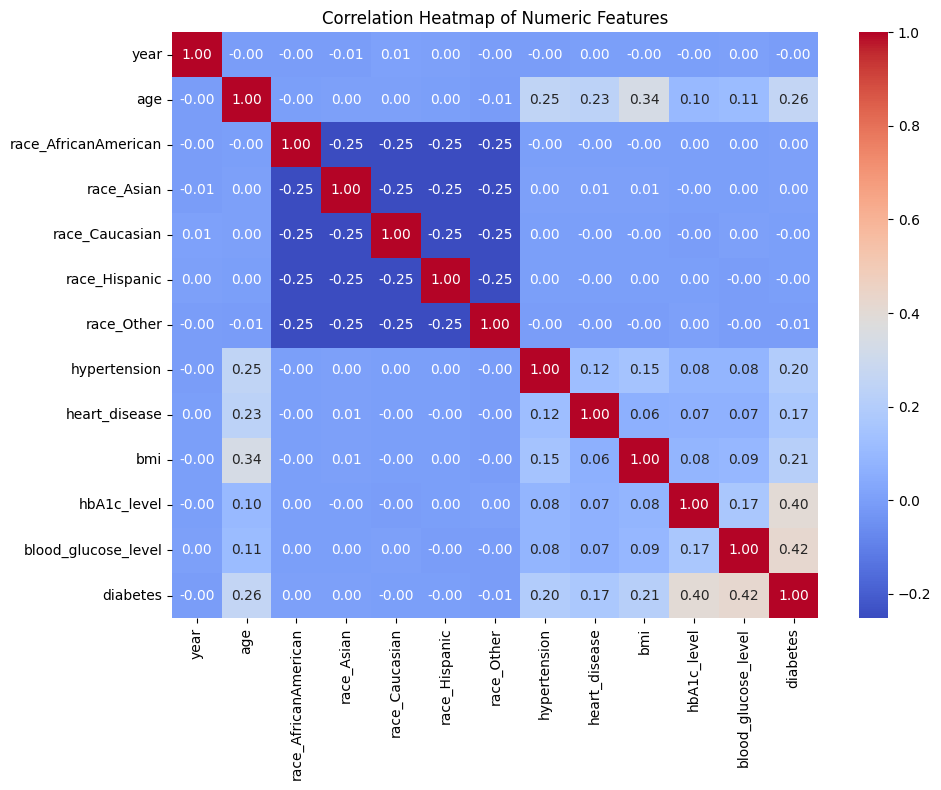

In [111]:
import matplotlib.gridspec as gridspec
import seaborn as sns

numeric_df = df.select_dtypes(include=[np.number])

# Correlation Heatmap

plt.figure(figsize=(10,8))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()




Relationship with diabetes:

The strongest positive correlations with diabetes are seen for:

Blood glucose level (0.42)

HbA1c level (0.40)

BMI (0.21)

Hypertension (0.20)

Heart disease (0.17)

This means that patients with higher blood sugar, higher HbA1c, higher BMI, or cardiovascular issues are more likely to have diabetes.

Age:

Age (0.26) has a moderate positive correlation with diabetes, suggesting older patients are slightly more likely to have diabetes.

Race variables:

Race indicators have correlations close to zero with diabetes, suggesting no strong linear relationship between race and diabetes in this dataset.

Other health measures:

BMI, hypertension, and heart disease show small to moderate positive correlations with diabetes, supporting the known association between obesity, cardiovascular health, and diabetes risk


The correlation analysis confirms that blood sugar levels, HbA1c, BMI, and cardiovascular conditions are the strongest indicators associated with diabetes in this dataset, while demographic variables like race have minimal linear effect. This insight is useful for identifying key risk factors and selecting features for further analysis or predictive modeling.

In [112]:
gender = df['gender'].value_counts().reset_index().rename(columns={0:'No of entries'})
gender

,gender,count
0,Female,58546
1,Male,41422
2,Other,18


In [113]:
df['gender'] = df['gender'].replace("Other", np.nan)
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

In [114]:
gender = df['gender'].value_counts().reset_index().rename(columns={0:'No of entries'})
gender

,gender,count
0,Female,58564
1,Male,41422


**Interpretation**: we replaced "other" with the most common value in gender and the female still has more entries that male

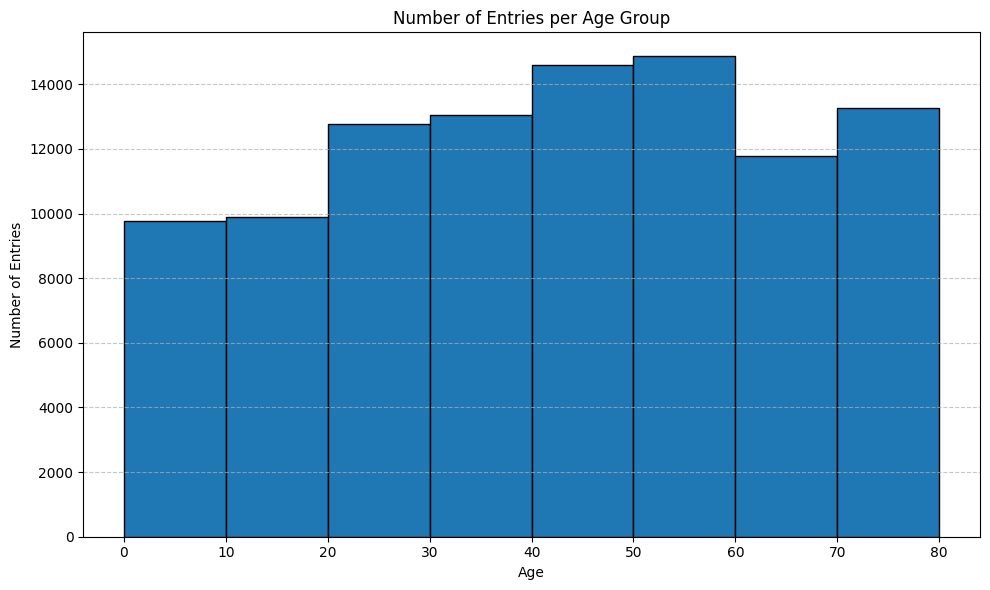

In [115]:
plt.figure(figsize=(10, 6))
plt.hist(df['age'], bins=[0,10,20,30,40,50,60,70,80], edgecolor='black')
plt.title('Number of Entries per Age Group')
plt.xlabel('Age')
plt.ylabel('Number of Entries')
plt.xticks([0,10,20,30,40,50,60,70,80])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Interpretation**:
Ages between 50-60 has the most entries and Ages 0-10 has the lowest number of entries, All the age groups are represented fairly in the dataset

<Figure size 600x400 with 0 Axes>

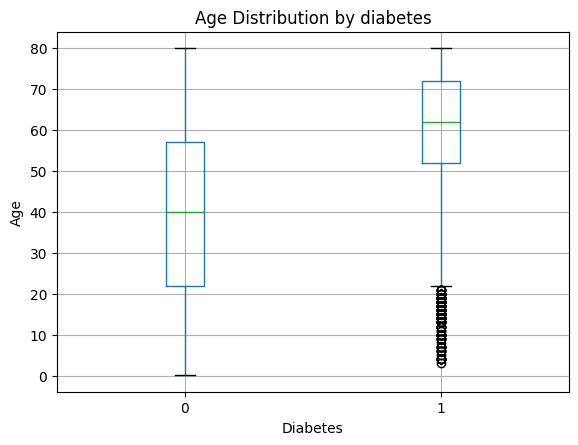

In [116]:
plt.figure(figsize=(6,4))
df.boxplot(column='age', by='diabetes')
plt.suptitle('')  # removes automatic title
plt.title('Age Distribution by diabetes')
plt.xlabel('Diabetes')
plt.ylabel('Age')
plt.show()

**Interpretation**: Diabetic individuals (1) have a higher median age (around early 60s) compared to non-diabetic individuals (0), whose median age is around the late 30s to early 40s.

The interquartile range (IQR) for diabetics is shifted toward older ages, indicating that diabetes is more prevalent among older individuals in the dataset.

Younger ages appear as outliers in the diabetic group, suggesting that while diabetes is less common among younger individuals, it can still occur.

The non-diabetic group shows a wider spread across younger and middle ages, with fewer extreme outliers.

In [117]:
#Exploring the races
race = df[['race_AfricanAmerican', 'race_Asian', 'race_Caucasian', 'race_Hispanic','race_Other']]


In [118]:
zeros = (race==0).sum()
ones = (race==1).sum()
race_counts = pd.DataFrame({'zero':zeros,'one':ones})
race_counts

,zero,one
race_AfricanAmerican,79765,20221
race_Asian,79979,20007
race_Caucasian,80113,19873
race_Hispanic,80099,19887
race_Other,79988,19998


**Interpretation**:
The distribution of the target classes across racial groups shows a consistent and balanced pattern,
with all races exhibiting approximately 80% of observations in the “zero” class and 20% in the “one” class. African American, Asian,
Caucasian, Hispanic, and Other groups all follow this same ratio with only minimal variation, suggesting that race does not introduce any notable imbalance or disproportion in the outcome variable. This uniformity indicates that the target variable is distributed similarly across racial categories,
implying that race is unlikely to be a strong predictor of class differences in this dataset.

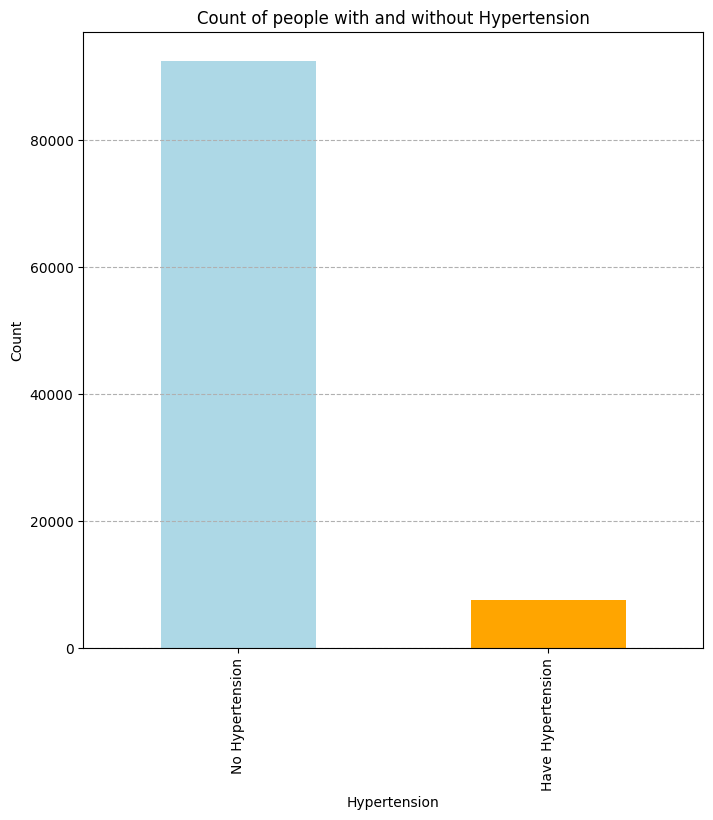

In [119]:
BP = df['hypertension'].value_counts()
BP.index=['No Hypertension','Have Hypertension']
BP

plt.figure(figsize=(8,8))
BP.plot(kind='bar', color=['lightblue','orange'], xlabel='Hypertension', ylabel='Count', title='Count of people with and without Hypertension')
plt.grid(axis='y', linestyle='--')
plt.show()

**Interpretation**:Most of the people do not have hypertension

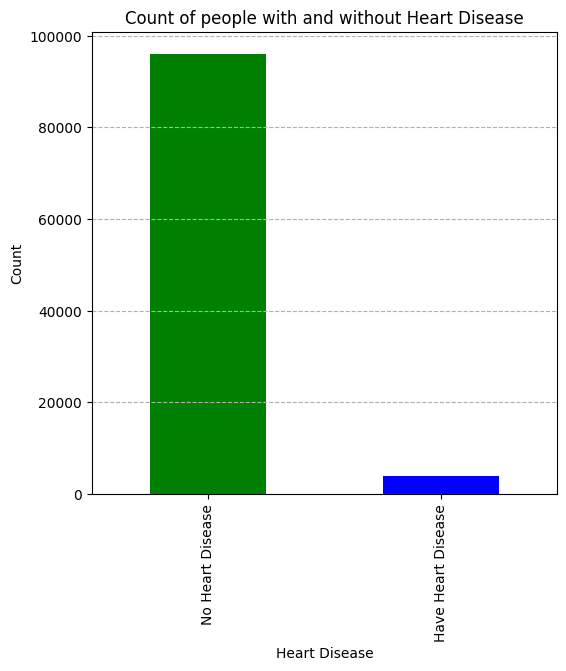

In [120]:
heart_disease = df['heart_disease'].value_counts()
heart_disease.index=['No Heart Disease', 'Have Heart Disease']
heart_disease


plt.figure(figsize=(6,6))
heart_disease.plot(kind='bar', color=['green','blue'], xlabel='Heart Disease', ylabel='Count', title='Count of people with and without Heart Disease')
plt.grid(axis='y', linestyle='--')
plt.show()


**Interpretation**: The amount of people with a heart disease is around 4000, only 4%, the rest have no heart disease



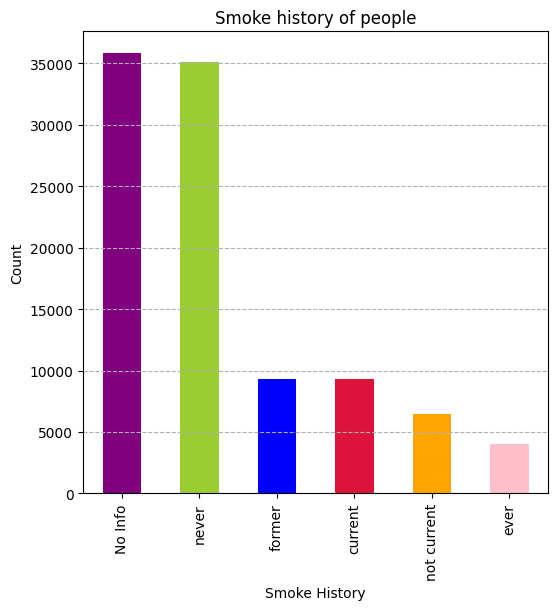

In [121]:

smoke = df['Smoking_Status'].value_counts()
smoke

plt.figure(figsize=(6,6))
smoke.plot(kind='bar', color=['purple','yellowgreen','blue','crimson','orange','pink'], xlabel='Smoke History', ylabel='Count', title='Smoke history of people')
plt.grid(axis='y', linestyle='--')
plt.show()

In [122]:
smoke_percentage = df['Smoking_Status'].value_counts(normalize=True) * 100
print("Percentage of each category in Smoking_Status:")
print(smoke_percentage)

Percentage of each category in Smoking_Status:
Smoking_Status
No Info        35.811014
never          35.095913
former          9.353309
current         9.287300
not current     6.447903
ever            4.004561
Name: proportion, dtype: float64


**Interpretation**: We can observe that we do not have the information of smoking history of a lot of people in this dataset. 35095 people have never smoked and 29089 people have some history of smoking.
We cannot drop this column as all values, including "No_Info" represent explicit patient responses rather than missing data, and "No_Info" didnot exceed 40% of data

## ***Further Cleaning and Preprocessing***

In [123]:
df = df.drop(['year', 'location','Clinical_Summary'], axis=1)
display(df)

,gender,age,race_AfricanAmerican,race_Asian,race_Caucasian,race_Hispanic,race_Other,hypertension,heart_disease,Smoking_Status,bmi,hbA1c_level,blood_glucose_level,diabetes
0,Female,32.0,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,Female,29.0,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,Male,18.0,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,Male,41.0,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,Female,52.0,1,0,0,0,0,0,0,never,23.75,6.5,90,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Female,33.0,0,0,0,0,1,0,0,never,21.21,6.5,90,0
99996,Female,80.0,0,1,0,0,0,0,0,No Info,36.66,5.7,100,0
99997,Male,46.0,0,1,0,0,0,0,0,ever,36.12,6.2,158,0
99998,Female,51.0,1,0,0,0,0,0,0,not current,29.29,6.0,155,0


The variables year, location, and Clinical_Summary were removed because they do not contribute meaningful or usable information to the analysis. The clinical notes contained in Clinical_Summary are unstructured text that is inconsistent, difficult to standardize, and not required for the scope of this study, making them unsuitable for inclusion without extensive natural language processing. Similarly, year and location offer little predictive value in this context, as they do not directly relate to the studied health outcomes and may introduce unnecessary noise or confounding.

#Boxplot For Outlier Detection

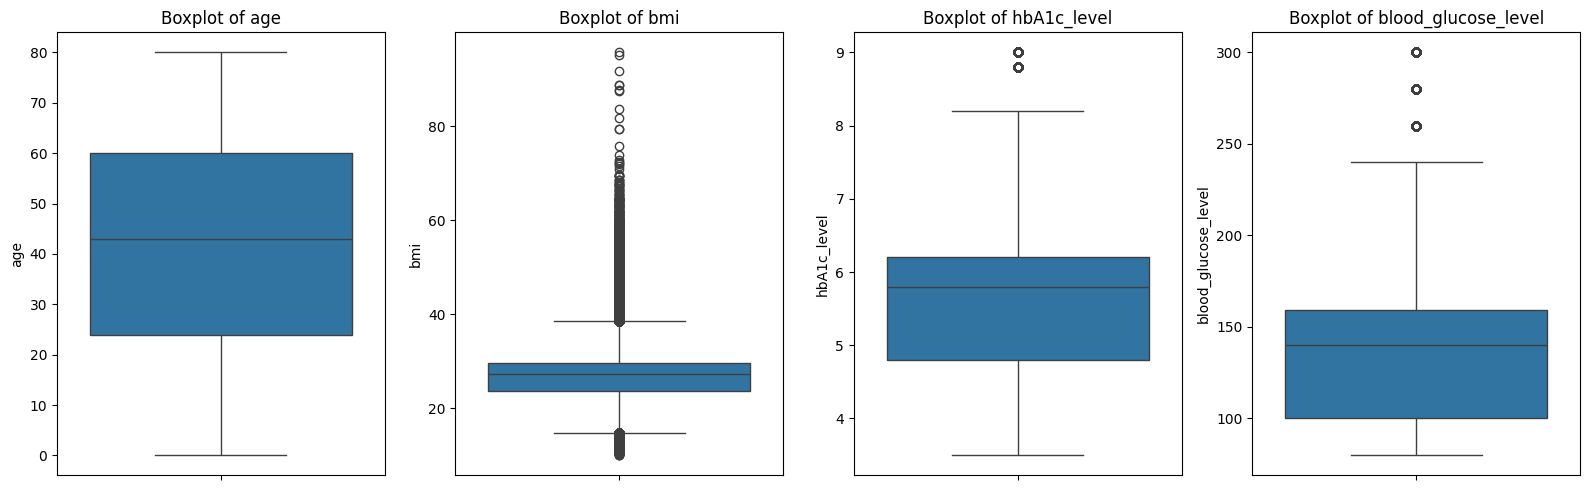

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numerical columns to plot
numerical_cols = ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level']

# Create subplots for each numerical column
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(16, 5))

# Iterate through columns and plot boxplots
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

**Interpretation**: Although several numerical features exhibit outliers, all were retained as they represent clinically plausible values rather than data errors and are important for diabetes classification.

# Encoding Categorical Variables

In [125]:
df = pd.get_dummies(df, columns=['Smoking_Status'], dtype=int)

In [126]:
df=pd.get_dummies(df,columns=["gender"],dtype=int,drop_first=True)


# Scaling Numeric Variables

In [127]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler_standard = StandardScaler()
df[['bmi', 'hbA1c_level', 'blood_glucose_level','age']] = scaler_standard.fit_transform(df[['bmi', 'hbA1c_level', 'blood_glucose_level','age']])
df.head()

,age,race_AfricanAmerican,race_Asian,race_Caucasian,race_Hispanic,race_Other,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes,Smoking_Status_No Info,Smoking_Status_current,Smoking_Status_ever,Smoking_Status_former,Smoking_Status_never,Smoking_Status_not current,gender_Male
0,-0.439057,0,0,0,0,1,0,0,-0.000116,-0.492699,-0.934929,0,0,0,0,0,1,0,0
1,-0.572294,0,1,0,0,0,0,0,-1.110521,-0.492699,-1.180578,0,0,0,0,0,1,0,0
2,-1.060829,0,0,0,0,1,0,0,-0.536485,-0.679498,0.538966,0,0,0,0,0,1,0,1
3,-0.039346,0,0,1,0,0,0,0,-0.000116,-1.426695,0.514401,0,0,0,0,0,1,0,1
4,0.449189,1,0,0,0,0,0,0,-0.537992,0.908296,-1.180578,0,0,0,0,0,1,0,0


All numerical variables were scaled using StandardScaler to ensure they are on a comparable scale, preventing features with larger magnitudes from disproportionately influencing the model and improving training stability and convergence.”

In [128]:
df.head(5)

,age,race_AfricanAmerican,race_Asian,race_Caucasian,race_Hispanic,race_Other,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes,Smoking_Status_No Info,Smoking_Status_current,Smoking_Status_ever,Smoking_Status_former,Smoking_Status_never,Smoking_Status_not current,gender_Male
0,-0.439057,0,0,0,0,1,0,0,-0.000116,-0.492699,-0.934929,0,0,0,0,0,1,0,0
1,-0.572294,0,1,0,0,0,0,0,-1.110521,-0.492699,-1.180578,0,0,0,0,0,1,0,0
2,-1.060829,0,0,0,0,1,0,0,-0.536485,-0.679498,0.538966,0,0,0,0,0,1,0,1
3,-0.039346,0,0,1,0,0,0,0,-0.000116,-1.426695,0.514401,0,0,0,0,0,1,0,1
4,0.449189,1,0,0,0,0,0,0,-0.537992,0.908296,-1.180578,0,0,0,0,0,1,0,0


## ***5. Feature Engineering & Selection***

A new interaction feature, age × BMI, was created to capture the combined effect of age and body mass index on diabetes risk, which may not be fully represented by each variable independently.

In [129]:
df_copy2= df.copy()


#1. Age BMI interaction
df_copy2['age_bmi'] = df_copy2['age'] * df_copy2['bmi']
target = 'diabetes'  # replace with your actual target column
df_copy2[['age', 'bmi', 'age_bmi', target]].corr()

,age,bmi,age_bmi,diabetes
age,1.000000,0.337426,-0.353719,0.258032
bmi,0.337426,1.000000,-0.255928,0.214359
age_bmi,-0.353719,-0.255928,1.000000,0.046559
diabetes,0.258032,0.214359,0.046559,1.000000


The interaction term age_bmi has a very weak correlation with diabetes (0.047).

This suggests that multiplying age and BMI together does not add meaningful predictive power for the target.
so this column will not be added to the main (df)

# Data Spliting

In [130]:
# Splitting the data
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

y = df['diabetes']
X = df.drop('diabetes', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

#Dealing with the imbalanced dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

Input features and the target variable were defined, and the data was split into training and testing sets before model training.

# Model selection and Training
Three classification models were applied: XGBoost, Random Forest, and Decision Tree on the resampled training data (`X_train_resampled`, `y_train_resampled`), then we will evaluate the test set (`X_test`), and report the accuracy, precision, recall, and F1-score for each model.

## Implement and Evaluate XGBoost Classifier



In [131]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 2. Instantiate an XGBClassifier model
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# 3. Train the XGBClassifier model using the resampled training data
xgb_model.fit(X_train_resampled, y_train_resampled)

# 4. Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# 5. Calculate and print the accuracy, precision, recall, and F1-score
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print(f"XGBoost Classifier Performance:")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1-Score: {f1_xgb:.4f}")

# Print the full classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:17:14] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier Performance:
Accuracy: 0.9712
Precision: 0.9209
Recall: 0.7264
F1-Score: 0.8121

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18284
           1       0.92      0.73      0.81      1714

    accuracy                           0.97     19998
   macro avg       0.95      0.86      0.90     19998
weighted avg       0.97      0.97      0.97     19998



## Implement and Evaluate RandomForest Classifier

In [132]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Instantiate a RandomForestClassifier model
rf_model = RandomForestClassifier(random_state=42)

# Train the RandomForestClassifier model using the resampled training data
rf_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Calculate and print the accuracy, precision, recall, and F1-score
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"\nRandom Forest Classifier Performance:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")

# Print the full classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Classifier Performance:
Accuracy: 0.9578
Precision: 0.7516
Recall: 0.7590
F1-Score: 0.7553

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     18284
           1       0.75      0.76      0.76      1714

    accuracy                           0.96     19998
   macro avg       0.86      0.87      0.87     19998
weighted avg       0.96      0.96      0.96     19998



## Implement and Evaluate DecisionTree Classifier



In [133]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Instantiate a DecisionTreeClassifier model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the DecisionTreeClassifier model using the resampled training data
dt_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)

# Calculate and print the accuracy, precision, recall, and F1-score
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print(f"\nDecision Tree Classifier Performance:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")

# Print the full classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


Decision Tree Classifier Performance:
Accuracy: 0.9461
Precision: 0.6613
Recall: 0.7608
F1-Score: 0.7075

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     18284
           1       0.66      0.76      0.71      1714

    accuracy                           0.95     19998
   macro avg       0.82      0.86      0.84     19998
weighted avg       0.95      0.95      0.95     19998



# **Feedback and Conclusion**

In diabetes prediction, recall is prioritized because false negatives can delay diagnosis and treatment. XGBoost is chosen as the best model because it provides the best balance between recall and precision, resulting in the highest F1-score among the tested models. While Decision Tree and Random Forest achieve similar or slightly higher recall, they suffer from lower precision, leading to more false positives. XGBoost maintains high precision with strong recall, along with the highest accuracy, making it the most reliable and balanced model for diabetes prediction.


***Recall Comparison***
(Diabetic Class = 1)

From highest to lowest recall:

Decision Tree: 0.7608

Random Forest: 0.7590

XGBoost: 0.7264

Interpretation:
The Decision Tree and Random Forest models achieve slightly higher recall than XGBoost, indicating they identify a marginally higher proportion of diabetic patients and produce fewer false negatives.

***F1-Score Interpretation***

Although XGBoost has lower recall, it achieves the highest F1-score (0.8121) due to its very high precision (0.9209). This indicates a better balance between correctly identifying diabetic patients and avoiding false positive predictions. In contrast, the Decision Tree sacrifices precision to achieve higher recall, while Random Forest provides a moderate balance but with a lower F1-score.

***Macro Average Interpretation***

Macro averages provide an unbiased evaluation by giving equal importance to both classes. XGBoost records the highest macro F1-score (0.90), demonstrating the most balanced performance across diabetic and non-diabetic classes despite class imbalance.

***Selecting the Best Model***

While Decision Tree and Random Forest achieve slightly higher recall, XGBoost is selected as the best model because it offers the strongest overall balance between recall and precision, the highest F1-score, and the highest accuracy. This makes XGBoost the most reliable and robust model for diabetes classification, effectively reducing false negatives without introducing excessive false positives.

# Hyperparameter Tuning for DecisionTree Classifier

In [134]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Define improved hyperparameter grid
param_dist = {
    'max_depth': [3, 5, 7, 9, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2']
}

# Instantiate Decision Tree with balanced class weights
dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

# RandomizedSearchCV setup
random_search = RandomizedSearchCV(
    estimator=dt_model,
    param_distributions=param_dist,
    n_iter=30,             # number of random combinations
    scoring='f1',          # optimize F1-score for balance between recall and precision
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit to training data (use resampled data if dataset is imbalanced)
random_search.fit(X_train_resampled, y_train_resampled)

# Best model from tuning
best_dt_model = random_search.best_estimator_

# Predict on test set
y_pred = best_dt_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Best hyperparameters found: ", random_search.best_params_)
print("\nEnhanced Decision Tree Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Full classification report
print("\nClassification Report (Enhanced Decision Tree):")
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best hyperparameters found:  {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': None, 'criterion': 'entropy'}

Enhanced Decision Tree Performance:
Accuracy: 0.9542
Precision: 0.7295
Recall: 0.7410
F1-Score: 0.7352

Classification Report (Enhanced Decision Tree):
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     18284
           1       0.73      0.74      0.74      1714

    accuracy                           0.95     19998
   macro avg       0.85      0.86      0.86     19998
weighted avg       0.95      0.95      0.95     19998



The enhanced Decision Tree shows clear improvements over the original model. Accuracy increased from 0.9461 to 0.9542, while precision for diabetic patients rose from 0.6613 to 0.7295, indicating fewer false positives. Recall remained high at 0.7410, slightly lower than the original 0.7608, ensuring most diabetic cases are still correctly identified. The F1-score improved from 0.7075 to 0.7352, reflecting a better balance between precision and recall.

Compared to the original model, the tuned Decision Tree achieves a more reliable and clinically meaningful performance. Hyperparameter optimization, including class weighting and F1-score scoring, reduced overfitting and mitigated excessive false positives. Overall, the post-tuning model generalizes better, providing a stronger and more balanced classifier for diabetes prediction.

#***Conclusion***


From a technical perspective, we applied a full machine learning workflow including data exploration, preprocessing, feature engineering, and modeling with Decision Tree, Random Forest, and XGBoost. While the Decision Tree was the worst-performing model initially, hyperparameter tuning slightly improved its F1-score and precision; however, it still did not surpass the performance of XGBoost. XGBoost consistently delivered the best balance of accuracy, precision, and recall, making it the most reliable model for correctly identifying diabetic patients.

From a business perspective, the tuned XGBoost model provides the highest clinical and operational value. Its superior predictive performance minimizes false negatives, ensuring timely identification of diabetic patients, and reduces false positives, preventing unnecessary interventions